In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.pipeline import Pipeline
from datetime import datetime
from timeit import default_timer as timer

from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score,StratifiedKFold, RandomizedSearchCV
from sklearn.svm import OneClassSVM

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

from sklearn.metrics import auc # Import auc for AUPRC
from sklearn.metrics import make_scorer, recall_score

# Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.over_sampling import BorderlineSMOTE

**Load the saved data from main notebook pkl files**

In [2]:
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/saved_model_components_backup'

Mounted at /content/drive


In [3]:
# Load the train/test splits
with open(os.path.join(save_dir, 'X_train.pkl'), 'rb') as f:
    loaded_X_train = pickle.load(f)
with open(os.path.join(save_dir, 'X_test.pkl'), 'rb') as f:
    loaded_X_test = pickle.load(f)
with open(os.path.join(save_dir, 'y_train.pkl'), 'rb') as f:
    loaded_y_train = pickle.load(f)
with open(os.path.join(save_dir, 'y_test.pkl'), 'rb') as f:
    loaded_y_test = pickle.load(f)
print("Loaded train/test data.")

# Load the dictionary of best models
with open(os.path.join(save_dir, 'best_models.pkl'), 'rb') as f:
    loaded_best_models = pickle.load(f)
print(f"Loaded best models from {os.path.join(save_dir, 'best_models.pkl')}")

print("\nVerification of loaded data types:")

print(f"Type of loaded_X_train: {type(loaded_X_train)}")
print(f"Type of loaded_best_models: {type(loaded_best_models)}")

Loaded train/test data.
Loaded best models from /content/drive/MyDrive/saved_model_components_backup/best_models.pkl

Verification of loaded data types:
Type of loaded_X_train: <class 'pandas.core.frame.DataFrame'>
Type of loaded_best_models: <class 'dict'>


In [4]:
X_train=loaded_X_train
X_test=loaded_X_test
y_train=loaded_y_train
y_test=loaded_y_test
X=pd.concat([X_train,X_test])
y=pd.concat([y_train,y_test])

X.shape,y.shape

((283726, 30), (283726,))

# Artificial Neural Network Multi-layer Perceptron with Keras and TensorFlow

In [ ]:
# Apply both SMOTE and scale the data

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = BorderlineSMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training samples: {len(X_train)}")
print(f"Resampled training samples: {len(X_train_resampled)}")

# Build and compile

model = Sequential([
    Dense(64, activation='relu',input_shape=(X_train_resampled.shape[1],)), # add an input shape to avoid warnings from the data #
    Dropout(0.2), # random dropout in each layer to force regularization and learn more patterns from latent space
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy', #  as it is a sigmoid output,  0,1
              metrics=[
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.Precision(name='precision'),
                  # prioritize AU PRC
                  tf.keras.metrics.AUC(name='auc_prc', curve='PR'),
              ])

# Define Early Stopping callback- to avoid long training runs
early_stopping_callback = EarlyStopping(
    monitor='val_recall', # Monitor validation recall  for fraud detection, this is our main aim .
    patience=20,          # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    mode='max',           # For recall, we want to maximize it
    verbose=1 # having the logs helps visulaize the whole process
)

print(f"Training Keras MLP with SMOTE...at ", datetime.now(),  " UTC")
mod_history = model.fit(X_train_resampled, y_train_resampled,
                        epochs=50, # Increased epochs since early stopping is used with patienc of 8
                        batch_size=32,
                        validation_data=(X_test_scaled, y_test),  # we can use the entire test data for validation set as wel
                        callbacks=[early_stopping_callback],
                        verbose=1)

# Evaluate the model on the test set
print("\nEvaluating Keras MLP on test data...")
loss, recall,precision, auc_prc = model.evaluate(X_test_scaled, y_test, verbose=0)

Original training samples: 226980
Resampled training samples: 453204
Training Keras MLP with SMOTE...at  2026-06-03 20:14:37.572590  UTC


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - auc_prc: 0.9981 - loss: 0.0449 - precision: 0.9876 - recall: 0.9835 - val_auc_prc: 0.6525 - val_loss: 0.0226 - val_precision: 0.1965 - val_recall: 0.8211
Epoch 2/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - auc_prc: 0.9990 - loss: 0.0241 - precision: 0.9924 - recall: 0.9932 - val_auc_prc: 0.6564 - val_loss: 0.0160 - val_precision: 0.2895 - val_recall: 0.8105
Epoch 3/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - auc_prc: 0.9991 - loss: 0.0208 - precision: 0.9934 - recall: 0.9943 - val_auc_prc: 0.6598 - val_loss: 0.0121 - val_precision: 0.3918 - val_recall: 0.8000
Epoch 4/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - auc_prc: 0.9991 - loss: 0.0196 - precision: 0.9937 - recall: 0.9946 - val_auc_prc: 0.6678 - val_loss: 0.0147 - val_precision: 0.2910 - val_recall: 0.8211
Epoch 5/50
14163/14163 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - auc_prc: 0.9991 - loss: 0.0185 - precision: 0.9939 - recall: 0.9950 - val_auc_prc: 0.6673

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,293 (48.02 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,196 (32.02 KB)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Precision: 0.2791519434628975
Recall: 0.8315789473684211
F1-Score: 0.41798941798941797
Confusion Matrix:
[[56447   204]
 [   16    79]]


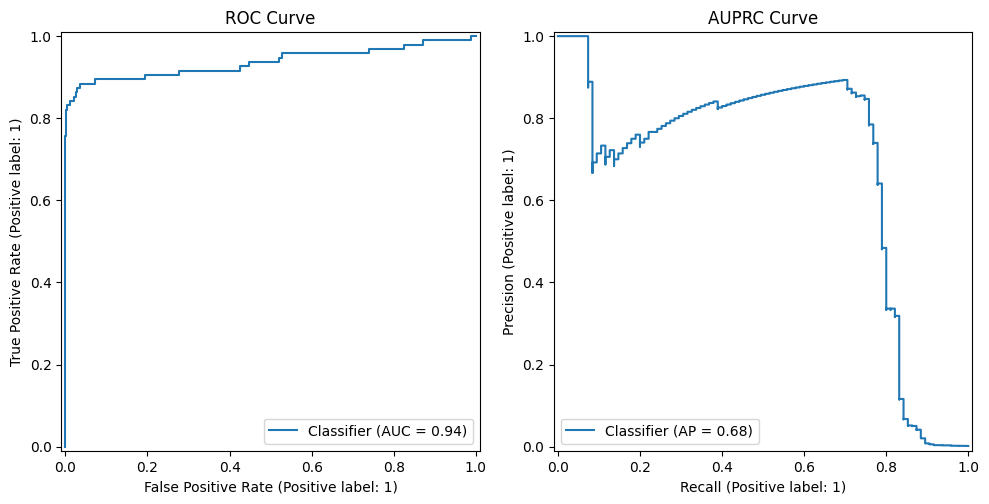

In [ ]:
y_preds_proba_mlp_keras = model.predict(X_test_scaled) # Get raw probabilities
y_preds_mlp_keras = (y_preds_proba_mlp_keras > 0.5).astype(int)  # Convert probabilities to binary predictions

# Plot confusion matrix and AUPRC and ROC AU curves
print(f"Precision: {precision_score(y_test, y_preds_mlp_keras)}")
print(f"Recall: {recall_score(y_test, y_preds_mlp_keras)}")
print(f"F1-Score: {f1_score(y_test, y_preds_mlp_keras)}")

cm = confusion_matrix(y_test, y_preds_mlp_keras)
print("Confusion Matrix:")
print(cm)
# Plot the PRC and ROC as subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# Plot the ROC curve
RocCurveDisplay.from_predictions(y_test, y_preds_proba_mlp_keras, ax=axs[0])
axs[0].set_title('ROC Curve')
# Plot the AUPRC curve
PrecisionRecallDisplay.from_predictions(y_test, y_preds_proba_mlp_keras, ax=axs[1])
axs[1].set_title('AUPRC Curve')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.32      0.83      0.46        95

    accuracy                           1.00     56746
   macro avg       0.66      0.91      0.73     56746
weighted avg       1.00      1.00      1.00     56746



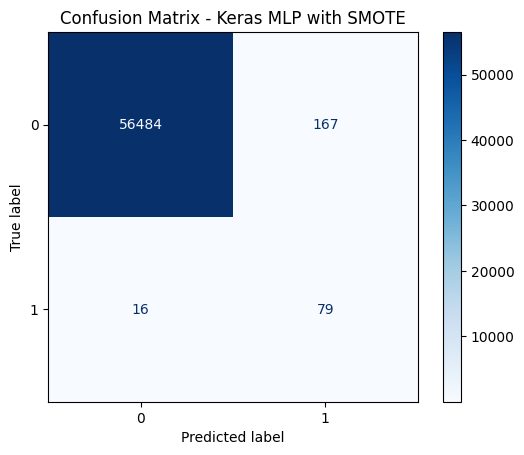

In [ ]:
# Classification report
print(classification_report(y_test, y_preds_mlp_keras))

# Plot the confusion matrix # add a different shade
ConfusionMatrixDisplay.from_predictions(y_test, y_preds_mlp_keras, cmap='Blues')
plt.title('Confusion Matrix - Keras MLP with SMOTE')
plt.show()

Visualizing Training and Validation Loss VS Accuracy



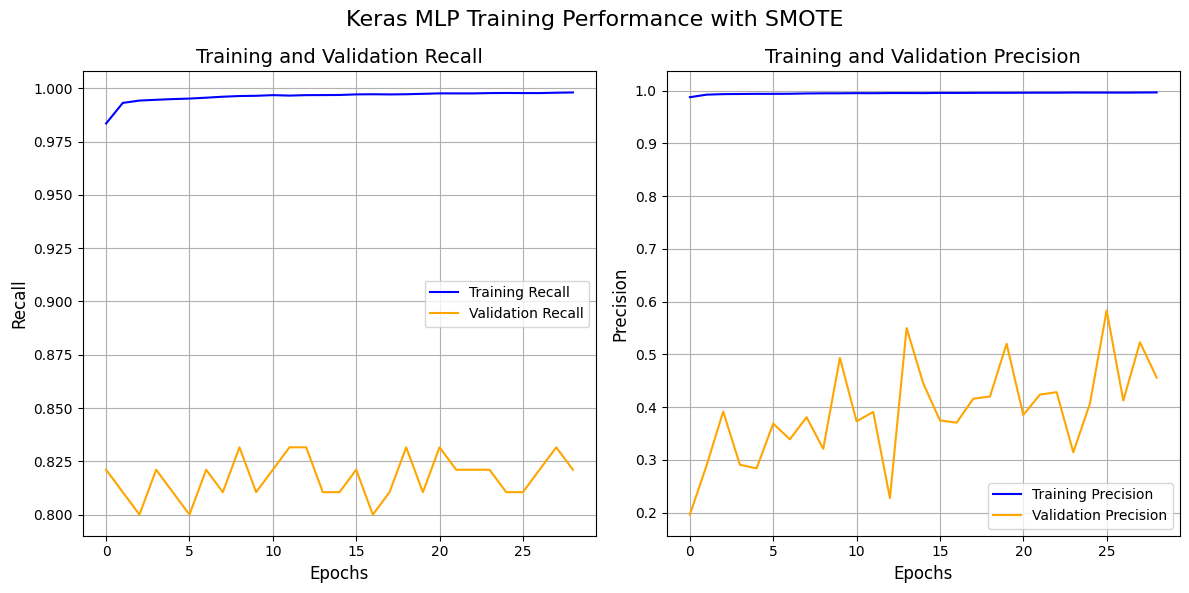

In [ ]:
plt.figure(figsize=(12, 6))

# Plot Training and Validation Recall
plt.subplot(1, 2, 1)
plt.plot(mod_history.history['recall'], label='Training Recall', color='blue')
plt.plot(mod_history.history['val_recall'], label='Validation Recall', color='orange')
plt.title('Training and Validation Recall', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend()
plt.grid(True)

# Plot Training and Validation Precision
plt.subplot(1, 2, 2)
plt.plot(mod_history.history['precision'], label='Training Precision', color='blue')
plt.plot(mod_history.history['val_precision'], label='Validation Precision', color='orange')
plt.title('Training and Validation Precision', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Keras MLP Training Performance with SMOTE", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Create a pandas dataframe with accuracy , precision , recall , F1- score
df=pd.DataFrame(columns=['Model','Accuracy','Precision','Recall','F1-Score'])
df.loc[0]=['Keras MLP with SMOTE',accuracy_score(y_test, y_preds_mlp_keras),precision_score(y_test, y_preds_mlp_keras),recall_score(y_test, y_preds_mlp_keras)
,f1_score(y_test, y_preds_mlp_keras)]
df

,Model,Accuracy,Precision,Recall,F1-Score
0,Keras MLP with SMOTE,0.996775,0.321138,0.831579,0.463343


**Conclusions on ANN**
ANN is able to find many hidden relationships within the normal and fraud data which shows up in the high recall and accuracy . Moreover it is able to draw a clear distinction between the positive and negative classes.

We see that the number of False negatives is quite admissable at 16 FN- 16 and TP-79 for comparing against the Keras implementation of MLP ANN against other models in the main notebook namely XGB and VC.

A very high recall score of 0.831579 and AUC ROC - 0.94 is quite a robust model for fraud detection.